<a href="https://colab.research.google.com/github/jaswanthbhavanam-03/SivaSaiJaswanthBhavanam_INFO5731_Spring2026/blob/main/Bhavanam_Siva_Assignment_02.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# **INFO5731 Assignment 2**

In this assignment, we will delve into various aspects of natural language processing (NLP) and text analysis. The tasks are designed to deepen your understanding of key NLP concepts and techniques, as well as to provide hands-on experience with practical applications.

Through these tasks, you'll gain practical experience in NLP techniques such as N-gram analysis, TF-IDF, word embedding model creation, and sentiment analysis dataset creation.

**Expectations**:
* Use the provided `.ipynb` document to write your code and respond to the questions. Avoid generating a new file.
* Write complete answers and run all the cells before submission.
* Make sure the submission is "clean"; i.e., no unnecessary code cells.
* Once finished, allow shared rights from the top right corner (see Canvas for details).
* **Note:** Use the same dataset you created in **Assignment 1** for **Questions 1–3**.

**Total points:** 100

**Deadline:** See Canvas

Late submission will have a penalty of **10% reduction for each day** after the deadline.


## Question 1 (25 points)

**Understand N-gram**

Write a **Python** program to conduct N-gram analysis based on the dataset you created in **Assignment 1**. You need to write **code from scratch instead of using any pre-existing libraries** to do so:

(1) Count the frequency of all the N-grams (**N = 3** and **N = 2**).

(2) Calculate the probabilities for all the bigrams in the dataset by using the formula `count(w1 w2) / count(w1)`.

For example, `count(really like) / count(really) = 1 / 3 = 0.33`.

(3) Extract all the noun phrases and calculate the relative probabilities of each review in terms of other reviews (abstracts, or tweets) by using the formula `frequency(noun phrase) / max frequency(noun phrase)` on the whole dataset. You may use NLP libraries (e.g., **spaCy** or **NLTK**) for noun phrase extraction.

Print out the result in a table with all noun phrases as the column names and all **100** reviews (abstracts, or tweets) as the row names.


In [23]:
import pandas as pd
from collections import defaultdict, Counter
import nltk
from nltk import word_tokenize, pos_tag, RegexpParser

nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('averaged_perceptron_tagger')
nltk.download('averaged_perceptron_tagger_eng')

# Load cleaned dataset from Assignment 1
df = pd.read_csv("semantic_Jaswanth_scholar_10000_clean.csv")

# Use clean_text column
df = df[['clean_text']].dropna().reset_index(drop=True)

# Convert text into token lists
documents = df['clean_text'].astype(str).tolist()
tokenized_docs = [doc.split() for doc in documents]

print("Total documents:", len(tokenized_docs))
print(df.head())

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!


Total documents: 9999
                                          clean_text
0  era burgeoning electric vehicle ev popularity ...
1  background meditation apps surged popularity r...
2  background human must able cope huge amount in...
3  growing number cloud based service led rising ...
4  diffusion generative model class machine learn...


In [24]:
# Part 1: Count bigrams and trigrams from scratch
unigram_counts = defaultdict(int)
bigram_counts = defaultdict(int)
trigram_counts = defaultdict(int)

for tokens in tokenized_docs:
    for i in range(len(tokens)):
        unigram_counts[tokens[i]] += 1

        if i < len(tokens) - 1:
            bigram = (tokens[i], tokens[i+1])
            bigram_counts[bigram] += 1

        if i < len(tokens) - 2:
            trigram = (tokens[i], tokens[i+1], tokens[i+2])
            trigram_counts[trigram] += 1
print("Total unique unigrams:", len(unigram_counts))
print("Total unique bigrams:", len(bigram_counts))
print("Total unique trigrams:", len(trigram_counts))

print("Top 20 Bigrams:")
for bg, count in sorted(bigram_counts.items(), key=lambda x: x[1], reverse=True)[:20]:
    print(bg, "->", count)

print("\nTop 20 Trigrams:")
for tg, count in sorted(trigram_counts.items(), key=lambda x: x[1], reverse=True)[:20]:
    print(tg, "->", count)



Total unique unigrams: 41216
Total unique bigrams: 731446
Total unique trigrams: 1191232
Top 20 Bigrams:
('machine', 'learning') -> 12019
('neural', 'network') -> 2858
('learning', 'model') -> 2158
('deep', 'learning') -> 1959
('learning', 'algorithm') -> 1769
('artificial', 'intelligence') -> 1736
('random', 'forest') -> 1641
('real', 'time') -> 1270
('learning', 'ml') -> 1173
('support', 'vector') -> 1159
('learning', 'technique') -> 1061
('vector', 'machine') -> 1008
('learning', 'method') -> 986
('result', 'show') -> 768
('state', 'art') -> 766
('learning', 'based') -> 716
('ml', 'model') -> 697
('decision', 'making') -> 694
('learning', 'approach') -> 678
('decision', 'tree') -> 673

Top 20 Trigrams:
('machine', 'learning', 'model') -> 1659
('machine', 'learning', 'algorithm') -> 1461
('machine', 'learning', 'ml') -> 1167
('support', 'vector', 'machine') -> 998
('machine', 'learning', 'technique') -> 845
('machine', 'learning', 'method') -> 713
('convolutional', 'neural', 'network

PART 2
The probabilities for all the bigrams in the dataset by using the formula count(w1 w2) / count(w1).



In [25]:
bigram_probabilities = {}

for bigram, count in bigram_counts.items():
    w1 = bigram[0]
    bigram_probabilities[bigram] = count / unigram_counts[w1]

print("Sample Bigram Probabilities:")
sample_probs = sorted(bigram_probabilities.items(), key=lambda x: x[1], reverse=True)[:20]

for bg, prob in sample_probs:
    print(f"{bg} -> {prob:.4f}")

Sample Bigram Probabilities:
('electrified', 'work') -> 1.0000
('clinicaltrials', 'gov') -> 1.0000
('chunk', 'sentence') -> 1.0000
('cibalackrot', 'dimer') -> 1.0000
('asexual', 'blood') -> 1.0000
('gametocyte', 'stage') -> 1.0000
('inactives', 'using') -> 1.0000
('hsp', 'silvestrol') -> 1.0000
('silvestrol', 'aglycone') -> 1.0000
('cytotoxicity', 'mammalian') -> 1.0000
('mainframe', 'environment') -> 1.0000
('wikipedians', 'case') -> 1.0000
('convict', 'supervised') -> 1.0000
('kerckhoffs', 'cryptographic') -> 1.0000
('polycation', 'nitric') -> 1.0000
('diversas', 'problem') -> 1.0000
('influenciam', 'dia') -> 1.0000
('referem', 'mudan') -> 1.0000
('desastres', 'naturais') -> 1.0000
('naturais', 'que') -> 1.0000


In [26]:
bigram_prob_df = pd.DataFrame(
    [(bg[0], bg[1], bigram_counts[bg], unigram_counts[bg[0]], prob)
     for bg, prob in bigram_probabilities.items()],
    columns=['w1', 'w2', 'count(w1 w2)', 'count(w1)', 'probability']
)

bigram_prob_df = bigram_prob_df.sort_values(by='probability', ascending=False).reset_index(drop=True)

bigram_prob_df.head(20)

,w1,w2,count(w1 w2),count(w1),probability
0,electrified,work,1,1,1.0
1,egime,dayali,1,1,1.0
2,dayali,geri,1,1,1.0
3,geri,yayilim,1,1,1.0
4,yayilim,yapay,1,1,1.0
5,sinir,aglari,1,1,1.0
6,keplan,meier,1,1,1.0
7,sulautumassa,osaksi,1,1,1.0
8,kehollista,ja,1,1,1.0
9,materiaalista,maailmaa,1,1,1.0


In [27]:
print("\nTop 20 Bigram Probabilities:")
for bg, prob in sorted(bigram_probabilities.items(), key=lambda x: x[1], reverse=True)[:20]:
    print(f"{bg} -> {prob:.4f}")



Top 20 Bigram Probabilities:
('electrified', 'work') -> 1.0000
('clinicaltrials', 'gov') -> 1.0000
('chunk', 'sentence') -> 1.0000
('cibalackrot', 'dimer') -> 1.0000
('asexual', 'blood') -> 1.0000
('gametocyte', 'stage') -> 1.0000
('inactives', 'using') -> 1.0000
('hsp', 'silvestrol') -> 1.0000
('silvestrol', 'aglycone') -> 1.0000
('cytotoxicity', 'mammalian') -> 1.0000
('mainframe', 'environment') -> 1.0000
('wikipedians', 'case') -> 1.0000
('convict', 'supervised') -> 1.0000
('kerckhoffs', 'cryptographic') -> 1.0000
('polycation', 'nitric') -> 1.0000
('diversas', 'problem') -> 1.0000
('influenciam', 'dia') -> 1.0000
('referem', 'mudan') -> 1.0000
('desastres', 'naturais') -> 1.0000
('naturais', 'que') -> 1.0000


In [28]:
print("Total bigrams:", len(bigram_probabilities))
print("Total rows in dataframe:", bigram_prob_df.shape)

Total bigrams: 731446
Total rows in dataframe: (731446, 5)


Due to the large number of bigrams in the dataset, only the top 20 bigrams and their probabilities are displayed for readability, while calculations were performed on the entire dataset.

Part 3

In [6]:
# Extract noun phrases for the whole dataset first
grammar = r"NP: {<JJ.*>*<NN.*>+}"
chunk_parser = RegexpParser(grammar)

def extract_noun_phrases(text):
    tokens = word_tokenize(text)
    tagged = pos_tag(tokens)
    tree = chunk_parser.parse(tagged)

    noun_phrases = []
    for subtree in tree.subtrees():
        if subtree.label() == 'NP':
            phrase = " ".join(word for word, tag in subtree.leaves())
            noun_phrases.append(phrase)
    return noun_phrases

# Whole dataset noun phrases
df['noun_phrases'] = df['clean_text'].apply(extract_noun_phrases)

# Global noun phrase counts from whole dataset
global_np_counts = Counter()
for np_list in df['noun_phrases']:
    global_np_counts.update(np_list)

# Only first 100 reviews for output table
first_100 = df.head(100).copy().reset_index(drop=True)

all_noun_phrases = sorted(global_np_counts.keys())
table_rows = []

for np_list in first_100['noun_phrases']:
    review_counter = Counter(np_list)
    row = {}
    for np_phrase in all_noun_phrases:
        freq_in_review = review_counter[np_phrase]
        max_freq_in_dataset = global_np_counts[np_phrase]
        row[np_phrase] = freq_in_review / max_freq_in_dataset if max_freq_in_dataset != 0 else 0
    table_rows.append(row)

noun_phrase_table = pd.DataFrame(table_rows, index=[f"review_{i+1}" for i in range(100)])

display(noun_phrase_table)
print("Shape:", noun_phrase_table.shape)

,aa adapts,aa air,aa explanation problem,aa joint,aa metabolism,aa phonation sample,aaa gaussian process gp,aaa obesity cholesterol level person,aaa technique,aaa term estimation accuracy exploration efficiency,...,zum,zum automatischen,zur kombination dieser extraktionsmodule mit visualisierung,zusammenfassung ziel der artikel soll ein,zutphen,zutphen heijen,zwei systematische fallstudien,zwicky transient factory,zymake improves,zynq model robustness
review_1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
review_2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
review_3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
review_4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
review_5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
review_96,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
review_97,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
review_98,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
review_99,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


Shape: (100, 241127)


## Question 2 (25 points)

**Understand TF-IDF and Document Representation**

Starting from the documents (all the reviews, abstracts, or tweets) collected for **Assignment 1**, write a **Python** program:

(1) Build the **document-term weight (`tf * idf`) matrix**.

(2) Rank the documents with respect to a query (design a query by yourself, for example, "An outstanding movie with a haunting performance and best character development") by using cosine similarity.

**Note:** You need to write **code from scratch instead of using any pre-existing libraries** to do so.


Cell 1 — Import and load dataset

In [8]:
# Write your code here
import pandas as pd
import math
from collections import Counter, defaultdict

# Load cleaned dataset from Assignment 1
df = pd.read_csv("semantic_Jaswanth_scholar_10000_clean.csv")

# Keep clean_text and remove missing rows
df = df[['clean_text']].dropna().reset_index(drop=True)

# Convert documents into token lists
documents = df['clean_text'].astype(str).tolist()
tokenized_docs = [doc.split() for doc in documents]

print("Total documents:", len(tokenized_docs))
print(df.head())







Total documents: 9999
                                          clean_text
0  era burgeoning electric vehicle ev popularity ...
1  background meditation apps surged popularity r...
2  background human must able cope huge amount in...
3  growing number cloud based service led rising ...
4  diffusion generative model class machine learn...


Part 1
Build document-term weight (TF-IDF) matrix from scratch

In [9]:
# Build vocabulary from scratch
vocab = sorted(set(word for doc in tokenized_docs for word in doc))
vocab_index = {word: i for i, word in enumerate(vocab)}

N = len(tokenized_docs)

# Calculate document frequency for each word
doc_freq = defaultdict(int)
for tokens in tokenized_docs:
    unique_words = set(tokens)
    for word in unique_words:
        doc_freq[word] += 1

# Calculate IDF for each word
idf = {}
for word in vocab:
    idf[word] = math.log(N / doc_freq[word])

# Build TF-IDF matrix
tf_idf_matrix = []

for tokens in tokenized_docs:
    term_counts = Counter(tokens)
    total_terms = len(tokens)

    row = [0.0] * len(vocab)

    for word, count in term_counts.items():
        tf = count / total_terms
        row[vocab_index[word]] = tf * idf[word]

    tf_idf_matrix.append(row)

# Convert to DataFrame
tf_idf_df = pd.DataFrame(tf_idf_matrix, columns=vocab)

print("TF-IDF Matrix Shape:", tf_idf_df.shape)
tf_idf_df.head()

TF-IDF Matrix Shape: (9999, 41216)


,aa,aaa,aaai,aabp,aac,aachen,aacr,aadac,aadel,aadt,...,zusammenfassung,zusammenhang,zutphen,zuverl,zwei,zwicky,zymake,zynq,zz,zzdlab
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


Part 2
Rank documents for a query using cosine similarity from scratch

In [10]:
# Design your own query
query = "machine learning model for natural language processing"

# Clean and tokenize query
query_tokens = query.lower().split()

# Build query TF-IDF vector from scratch
query_counts = Counter(query_tokens)
query_total_terms = len(query_tokens)

query_vector = [0.0] * len(vocab)

for word, count in query_counts.items():
    if word in vocab_index:
        tf = count / query_total_terms
        query_vector[vocab_index[word]] = tf * idf[word]

# Cosine similarity function
def cosine_similarity(vec1, vec2):
    dot_product = sum(a * b for a, b in zip(vec1, vec2))

    norm1 = math.sqrt(sum(a * a for a in vec1))
    norm2 = math.sqrt(sum(b * b for b in vec2))

    if norm1 == 0 or norm2 == 0:
        return 0.0

    return dot_product / (norm1 * norm2)

# Rank documents
scores = []
for i, doc_vector in enumerate(tf_idf_matrix):
    sim = cosine_similarity(query_vector, doc_vector)
    scores.append((i, sim))

ranked_docs = sorted(scores, key=lambda x: x[1], reverse=True)

# Show top 10 ranked documents
top_10 = ranked_docs[:10]

results = []
for rank, (doc_index, score) in enumerate(top_10, start=1):
    results.append({
        "Rank": rank,
        "Document_Index": doc_index,
        "Cosine_Similarity": score,
        "Document_Text": documents[doc_index][:200]
    })

ranked_results_df = pd.DataFrame(results)

print("Query:", query)
ranked_results_df

Query: machine learning model for natural language processing


,Rank,Document_Index,Cosine_Similarity,Document_Text
0,1,7494,0.438925,background natural language processing increas...
1,2,8587,0.407089,deep learning technique emerged key catalyst i...
2,3,2392,0.325463,article examines newest direction artificial i...
3,4,3617,0.320154,study investigate natural language processing ...
4,5,2868,0.317687,sentiment analysis essential component natural...
5,6,6833,0.302880,paper aim solve huge amount noise current inte...
6,7,7940,0.296524,natural language processing nlp transformative...
7,8,730,0.284504,exponential growth data modern organization ab...
8,9,3084,0.282871,constant growth world wide web number document...
9,10,7883,0.282490,natural language processing nlp emerged transf...


For Question 2, the cleaned text dataset from Assignment 1 was used. The TF-IDF matrix was constructed from scratch by computing term frequency (TF) and inverse document frequency (IDF) manually. Document ranking was then performed using cosine similarity between the query vector and each document vector.

## Question 3 (25 points)

**Create your own word embedding model**

Use the data you collected for **Assignment 1** to build a word embedding model. You may use existing libraries (e.g., **gensim** or **transformers**) for training embeddings.

(1) Train a **300-dimensional** word embedding model (e.g., **Word2Vec, GloVe, ULMFiT, or a fine-tuned BERT model**).

(2) Visualize the embeddings using **PCA** or **t-SNE** in 2D. Create a scatter plot of at least **20 words** and show how similar words cluster together.

(3) Calculate the **cosine similarity** between a few pairs of words to examine whether the model captures semantic similarity accurately.

**References:**

- https://machinelearningmastery.com/develop-word-embeddings-python-gensim/
- https://jaketae.github.io/study/word2vec/


Train a 300-dimensional word embedding model

In [11]:
!pip install gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 40.7 MB/s eta 0:00:00


In [12]:
# Write your code here
import pandas as pd
from gensim.models import Word2Vec

# Load cleaned dataset from Assignment 1
df = pd.read_csv("semantic_Jaswanth_scholar_10000_clean.csv")

# Keep clean_text and remove missing rows
df = df[['clean_text']].dropna().reset_index(drop=True)

# Prepare sentences for Word2Vec
sentences = [text.split() for text in df['clean_text'].astype(str)]

# Train 300-dimensional Word2Vec model
word2vec_model = Word2Vec(
    sentences=sentences,
    vector_size=300,
    window=5,
    min_count=2,
    workers=4,
    sg=1
)

print("Word2Vec model trained successfully.")
print("Vector size:", word2vec_model.vector_size)
print("Vocabulary size:", len(word2vec_model.wv.index_to_key))

# Show a few sample words
print("\nSample similar words:")
sample_words = ['machine', 'learning', 'model', 'language', 'data']
for word in sample_words:
    if word in word2vec_model.wv:
        print(f"\nTop 5 similar words for '{word}':")
        print(word2vec_model.wv.most_similar(word, topn=5))







Word2Vec model trained successfully.
Vector size: 300
Vocabulary size: 24609

Sample similar words:

Top 5 similar words for 'machine':
[('utilised', 0.6819787621498108), ('rapidminer', 0.6677371859550476), ('utilises', 0.6648715734481812), ('chine', 0.6632422208786011), ('mlts', 0.661675214767456)]

Top 5 similar words for 'learning':
[('subfield', 0.7162772417068481), ('dml', 0.7004280090332031), ('timeseries', 0.6937950253486633), ('ccfd', 0.6844356060028076), ('mlts', 0.681531548500061)]

Top 5 similar words for 'model':
[('metamodels', 0.6947364211082458), ('generalisation', 0.6874620318412781), ('mla', 0.6871362328529358), ('lrp', 0.685833215713501), ('tabnet', 0.6856667995452881)]

Top 5 similar words for 'language':
[('nlp', 0.7237166166305542), ('arabic', 0.7222453951835632), ('asl', 0.7038632035255432), ('multilingual', 0.7018611431121826), ('spoken', 0.6869435906410217)]

Top 5 similar words for 'data':
[('basically', 0.6120718717575073), ('collection', 0.5931366086006165), 

Visualize embeddings in 2D using PCA

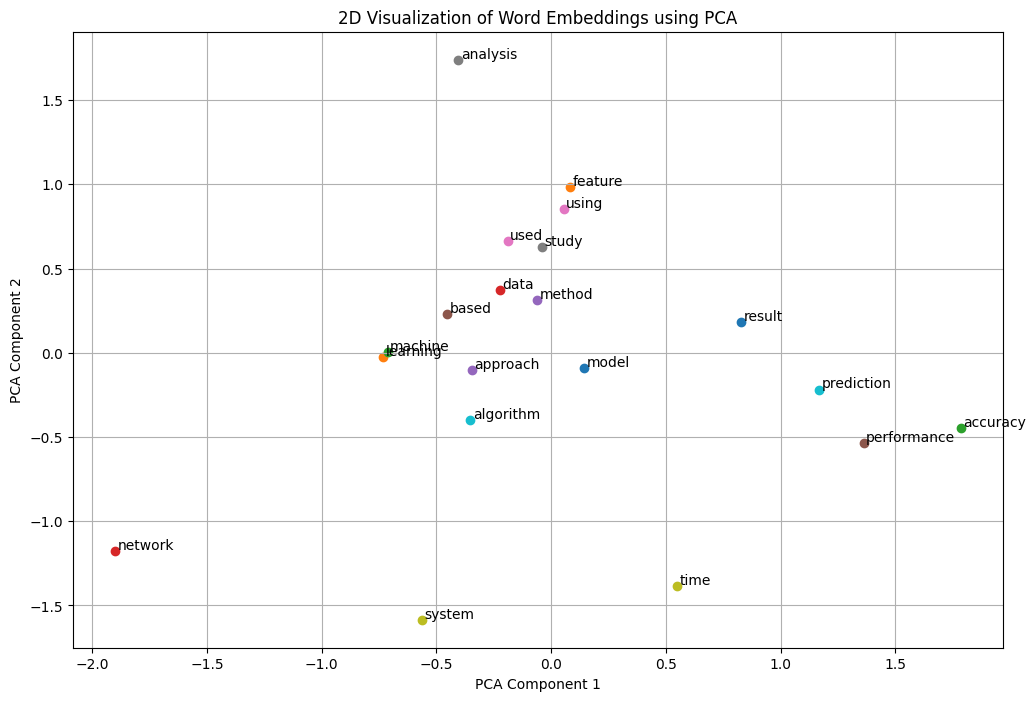

In [13]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Select at least 20 words from the vocabulary
words_to_plot = []
for word in word2vec_model.wv.index_to_key:
    if len(words_to_plot) < 20:
        words_to_plot.append(word)
    else:
        break

# Get vectors for selected words
word_vectors = [word2vec_model.wv[word] for word in words_to_plot]

# Reduce dimensions to 2D using PCA
pca = PCA(n_components=2)
word_vectors_2d = pca.fit_transform(word_vectors)

# Scatter plot
plt.figure(figsize=(12, 8))

for i, word in enumerate(words_to_plot):
    x = word_vectors_2d[i][0]
    y = word_vectors_2d[i][1]
    plt.scatter(x, y)
    plt.text(x + 0.01, y + 0.01, word, fontsize=10)

plt.title("2D Visualization of Word Embeddings using PCA")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.grid(True)
plt.show()

Calculate cosine similarity between word pairs

In [14]:
# Word pairs to test semantic similarity
word_pairs = [
    ('machine', 'learning'),
    ('language', 'text'),
    ('model', 'algorithm'),
    ('data', 'information'),
    ('neural', 'network')
]

print("Cosine Similarity Between Word Pairs:\n")

for w1, w2 in word_pairs:
    if w1 in word2vec_model.wv and w2 in word2vec_model.wv:
        similarity = word2vec_model.wv.similarity(w1, w2)
        print(f"{w1} - {w2}: {similarity:.4f}")
    else:
        print(f"{w1} - {w2}: one or both words not found in vocabulary")

Cosine Similarity Between Word Pairs:

machine - learning: 0.6350
language - text: 0.5875
model - algorithm: 0.5638
data - information: 0.3917
neural - network: 0.6507


For Question 3, a 300-dimensional Word2Vec embedding model was trained using the cleaned text data from Assignment 1. Gensim was used for training the embeddings. PCA was then applied to reduce the word vectors into two dimensions for visualization, and cosine similarity was calculated for selected word pairs to examine semantic similarity.

## Question 4 (20 Points)

**Create your own training and evaluation dataset for an NLP task.**

**You do not need to write a program for this question.**

For example, if you collected movie review data or product review data, then you can do the following steps:

* Read each review (abstract or tweet) you collected in detail, and annotate each review with a sentiment (**positive, negative, or neutral**).

* Save the annotated dataset into a **CSV** file with three columns (`document_id`, `clean_text`, `sentiment`), upload the CSV file to GitHub, and submit the file link below.

This dataset will be used for **Assignment 4: Sentiment Analysis and Text Classification**.


1. Which NLP task would you like to perform on your selected dataset (**NER, summarization, sentiment analysis, or text classification**)?
2. Explain the labeling schema you used and mention the labels.

3. You may use AI assistance for labeling the data only.


### NLP Task Selected
The NLP task selected for this assignment is **Text Classification (Topic Classification)**.

### Labeling Schema
Each document in the dataset was labeled based on its primary topic using keyword-based classification. The labeling process involved identifying important keywords such as "machine learning", "deep learning", "neural networks", and "natural language processing" within the text.

### Labels Used
The following labels were used:
- Machine Learning
- Natural Language Processing
- Deep Learning
- Data Mining
- Other

### AI Assistance
AI assistance was used to automate the labeling process using rule-based keyword matching. No AI was used for generating the dataset itself.

In [ ]:
# The GitHub link of your final csv file
# Link:
https://github.com/jaswanthbhavanam-03/SivaSaiJaswanthBhavanam_INFO5731_Spring2026/blob/main/Jaswanth_Asigment02_Q4_labeled_dataset.csv



# Mandatory Question (5 Points)

Provide your thoughts on the assignment by filling this survey link. What did you find challenging, and what aspects did you enjoy? Your opinion on the provided time to complete the assignment.

In [ ]:
# Type your answer
This assignment was very helpful in understanding core NLP concepts such as N-grams, TF-IDF, and word embeddings. The most challenging part was implementing the algorithms from scratch, especially calculating TF-IDF and bigram probabilities without using built-in libraries. It required careful understanding of the formulas and handling large datasets efficiently.

I also found the noun phrase extraction and visualization of word embeddings interesting, as they helped me better understand how text data can be structured and analyzed. The word embedding visualization using PCA was particularly enjoyable.

The labeling task in Question 4 was slightly time-consuming due to the size of the dataset, but it helped in understanding how datasets are prepared for machine learning tasks.

Overall, the assignment was well-designed and covered important NLP concepts. The time provided was mostly sufficient, although a little more time would have been helpful for labeling and debugging.